# Step 31 — heatmaps: the same genes in every study, each in its own units

**Data types: RNA_array, bulk_RNA_seq, scRNA_seq pseudobulk.** **Reads:** `step30_cross_platform.rds`,
`step28_ifn.rds`, `step10_site_A.rds`, `step23_*`, `step25_*`.
**Writes:** `figures/fig31_cross_platform_{GSE65391_A,GSE232381,GSE135779}.png`.

One heatmap per study, drawn at that study with its own data. The rows are the marker genes every
study measures, in the same order, plus the six interferon genes. The values are standardised within
the study (mean 0 and SD 1 over its own patients), so colours compare **patterns**, not levels, across
platforms. Columns are split by the cross-platform federated endotype of step 30.

In [1]:
source("../src/paths.R")
source("../src/figures.R")
x  <- readRDS(art("step30_cross_platform.rds")); sh <- readRDS(art("step26_shared.rds"))
ifn6 <- read_gene_set("ifn-type1-6.txt")
e1 <- intersect(sh$markers[1:30], x$genes); e2 <- intersect(sh$markers[31:60], x$genes)
rows <- unique(c(e1, e2, ifn6))
row_block <- factor(ifelse(rows %in% ifn6, "interferon", ifelse(rows %in% e1, "marks E1", "marks E2")),
                    levels = c("marks E1", "marks E2", "interferon"))
EN <- c("E1-like" = "#D55E7A", "E2-like" = "#4E9A06")
study_heatmap <- function(E, lab, ann_df, ann_col, title) {
  M <- t(scale(t(E[rows, ]))); M[M > 2.5] <- 2.5; M[M < -2.5] <- -2.5
  Heatmap(M, name = "z within study", col = Z_COL, column_split = factor(lab, levels = names(EN)),
    row_split = row_block, cluster_row_slices = FALSE, cluster_column_slices = FALSE,
    clustering_method_columns = "ward.D2", show_column_dend = FALSE, show_row_dend = FALSE,
    show_column_names = FALSE, row_names_gp = gpar(fontsize = 6), row_title_rot = 0, row_title_gp = gpar(fontsize = 9),
    column_title_gp = gpar(fontsize = 10),
    top_annotation = HeatmapAnnotation(df = cbind(endotype = lab, ann_df), col = c(list(endotype = EN), ann_col),
                                       annotation_name_gp = gpar(fontsize = 8), na_col = "grey95"))
}
render <- function(ht, file, title) {
  png(fig(file), width = 2200, height = 1700, res = 170)
  draw(ht, column_title = title, column_title_gp = gpar(fontsize = 13, fontface = "bold"), merge_legend = TRUE)
  invisible(dev.off())
}

In [2]:
d <- readRDS(site_file("10", "A")); m <- d$meta
core <- { v <- m[m$split == "discovery", ]; v <- v[order(v$subject, v$visit), ]; rownames(v)[!duplicated(v$subject)] }
lab <- x$names[x$with_rnaseq$labels$A]
ht_a <- study_heatmap(d$E[, core], lab, data.frame("interferon score" = m[core, "ifn_score"], stage = m[core, "stage"], check.names = FALSE),
                      list("interferon score" = IFN_COL, stage = STAGE_COL), "")
render(ht_a, "fig31_cross_platform_GSE65391_A.png", "GSE65391 RNA_array, whole blood, site A discovery patients")

In [3]:
b <- readRDS(art("step23_GSE232381.rds")); ifn <- readRDS(art("step28_ifn.rds"))
ht_b <- study_heatmap(b$E, x$names[x$with_rnaseq$labels$GSE232381],
                      data.frame("nephritis activity" = as.character(b$meta$ln_activity),
                                 "relative interferon score" = ifn$GSE232381$ifn_score, check.names = FALSE),
                      list("nephritis activity" = c(inactive = "#F4A582", active = "#B2182B"),
                           "relative interferon score" = colorRamp2(c(-2, 0, 2), c("#2166AC", "white", "#B2182B"))), "")
render(ht_b, "fig31_cross_platform_GSE232381.png", "GSE232381 bulk_RNA_seq, peripheral blood cells")

In [4]:
p <- readRDS(art("step25_GSE135779.rds")); j <- p$meta$disease == "SLE"
ht_p <- study_heatmap(p$E[, j], x$names[x$with_rnaseq$labels$GSE135779],
                      data.frame("interferon score" = ifn$GSE135779[j, "ifn_score"], age = p$meta$age[j], check.names = FALSE),
                      list("interferon score" = colorRamp2(c(-1, 0, 4, 8), c("#2166AC", "white", "#F4A582", "#B2182B")),
                           age = colorRamp2(c(7, 19), c("white", "#3f007d"))), "")
render(ht_p, "fig31_cross_platform_GSE135779.png", "GSE135779 scRNA_seq pseudobulk, PBMC, children with SLE")

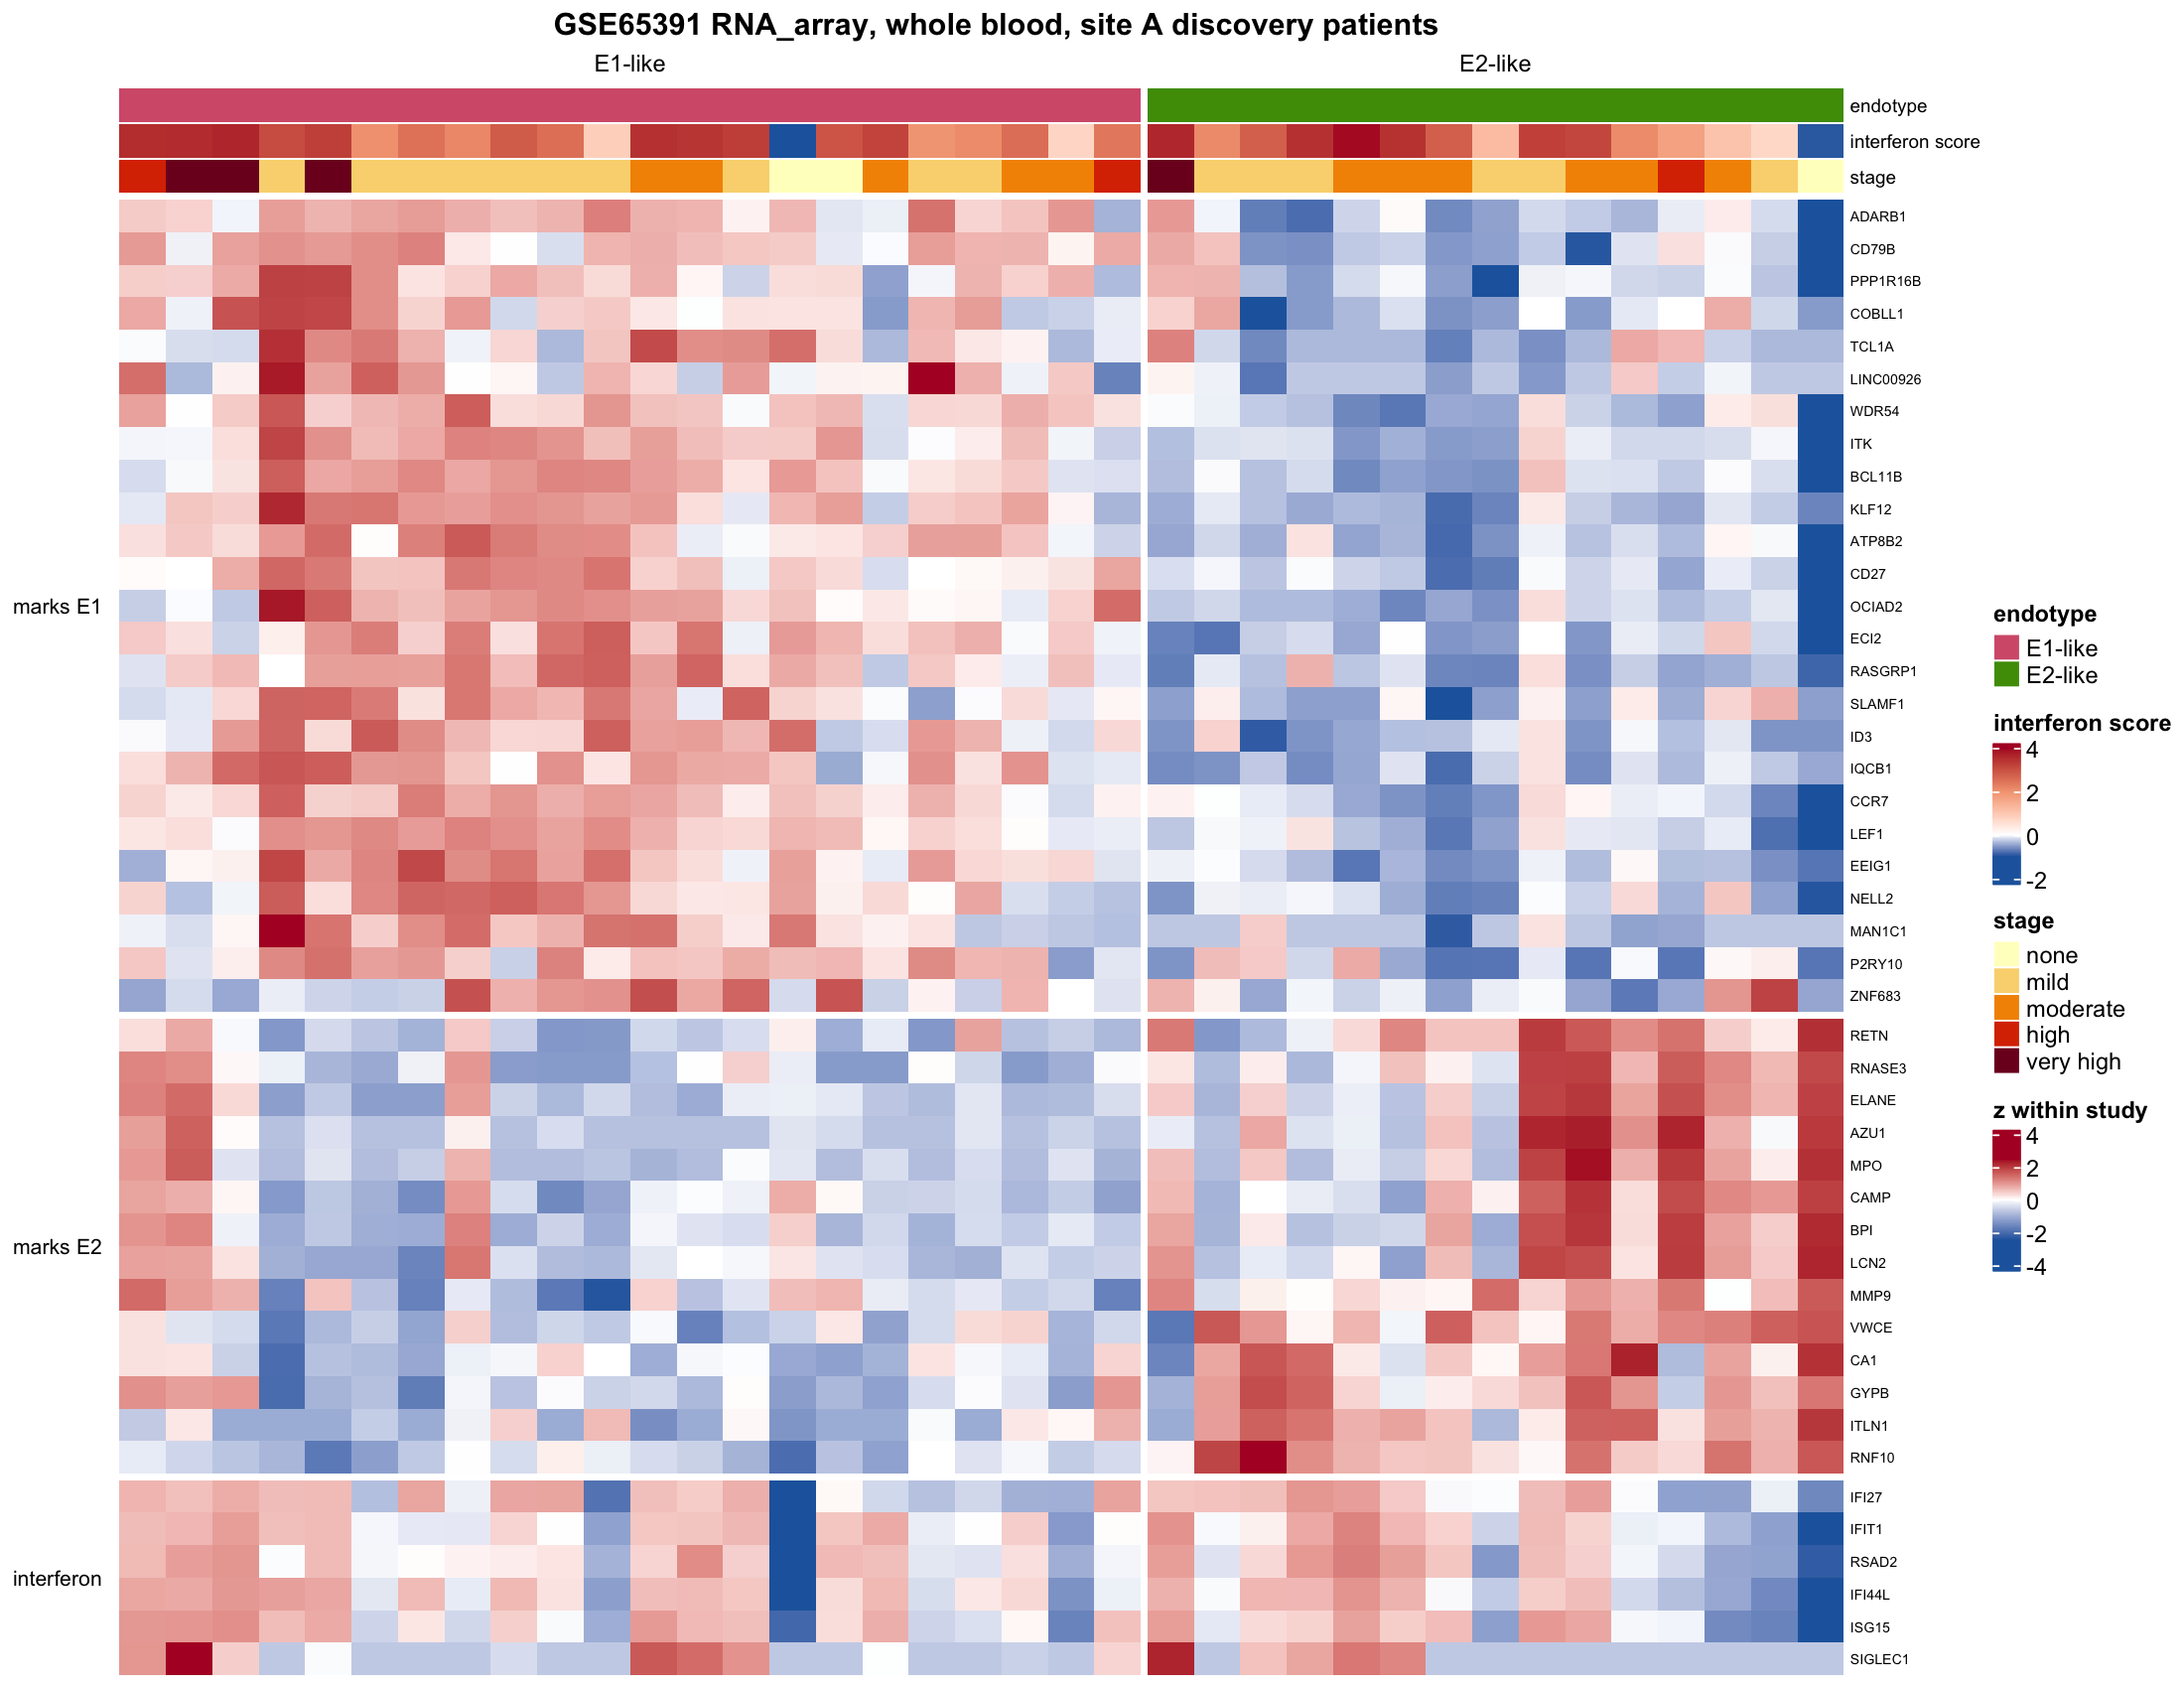

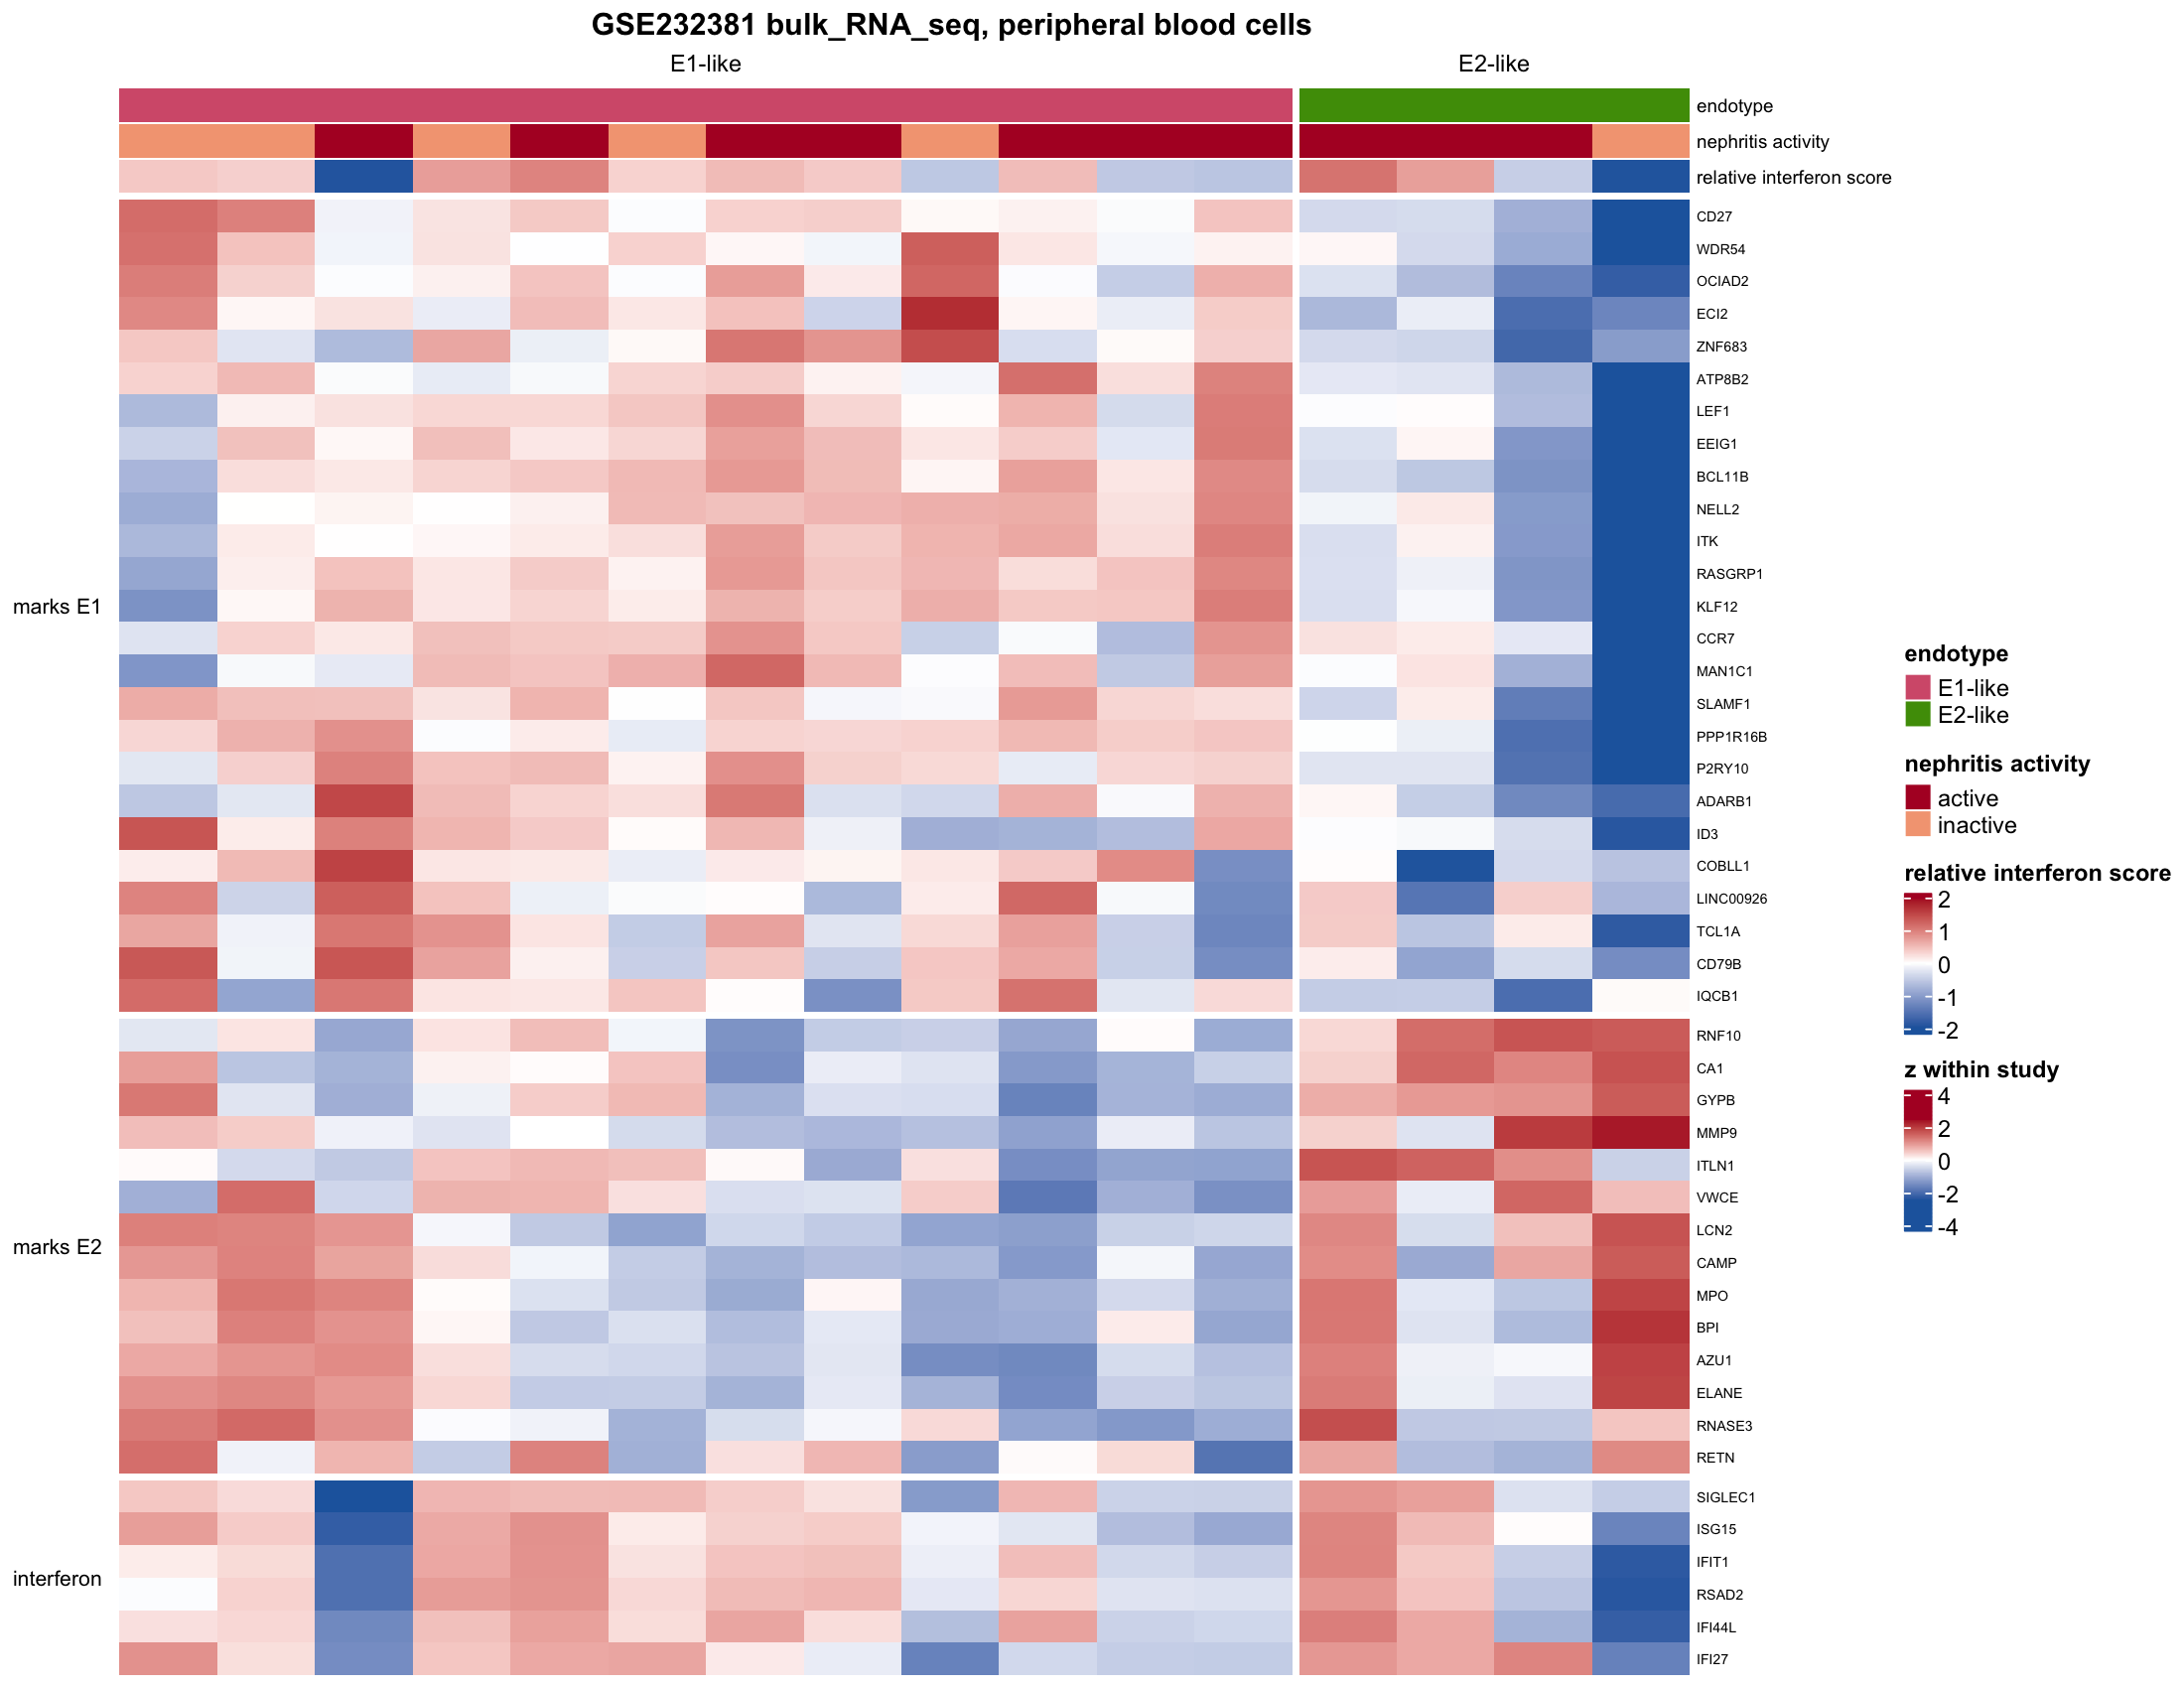

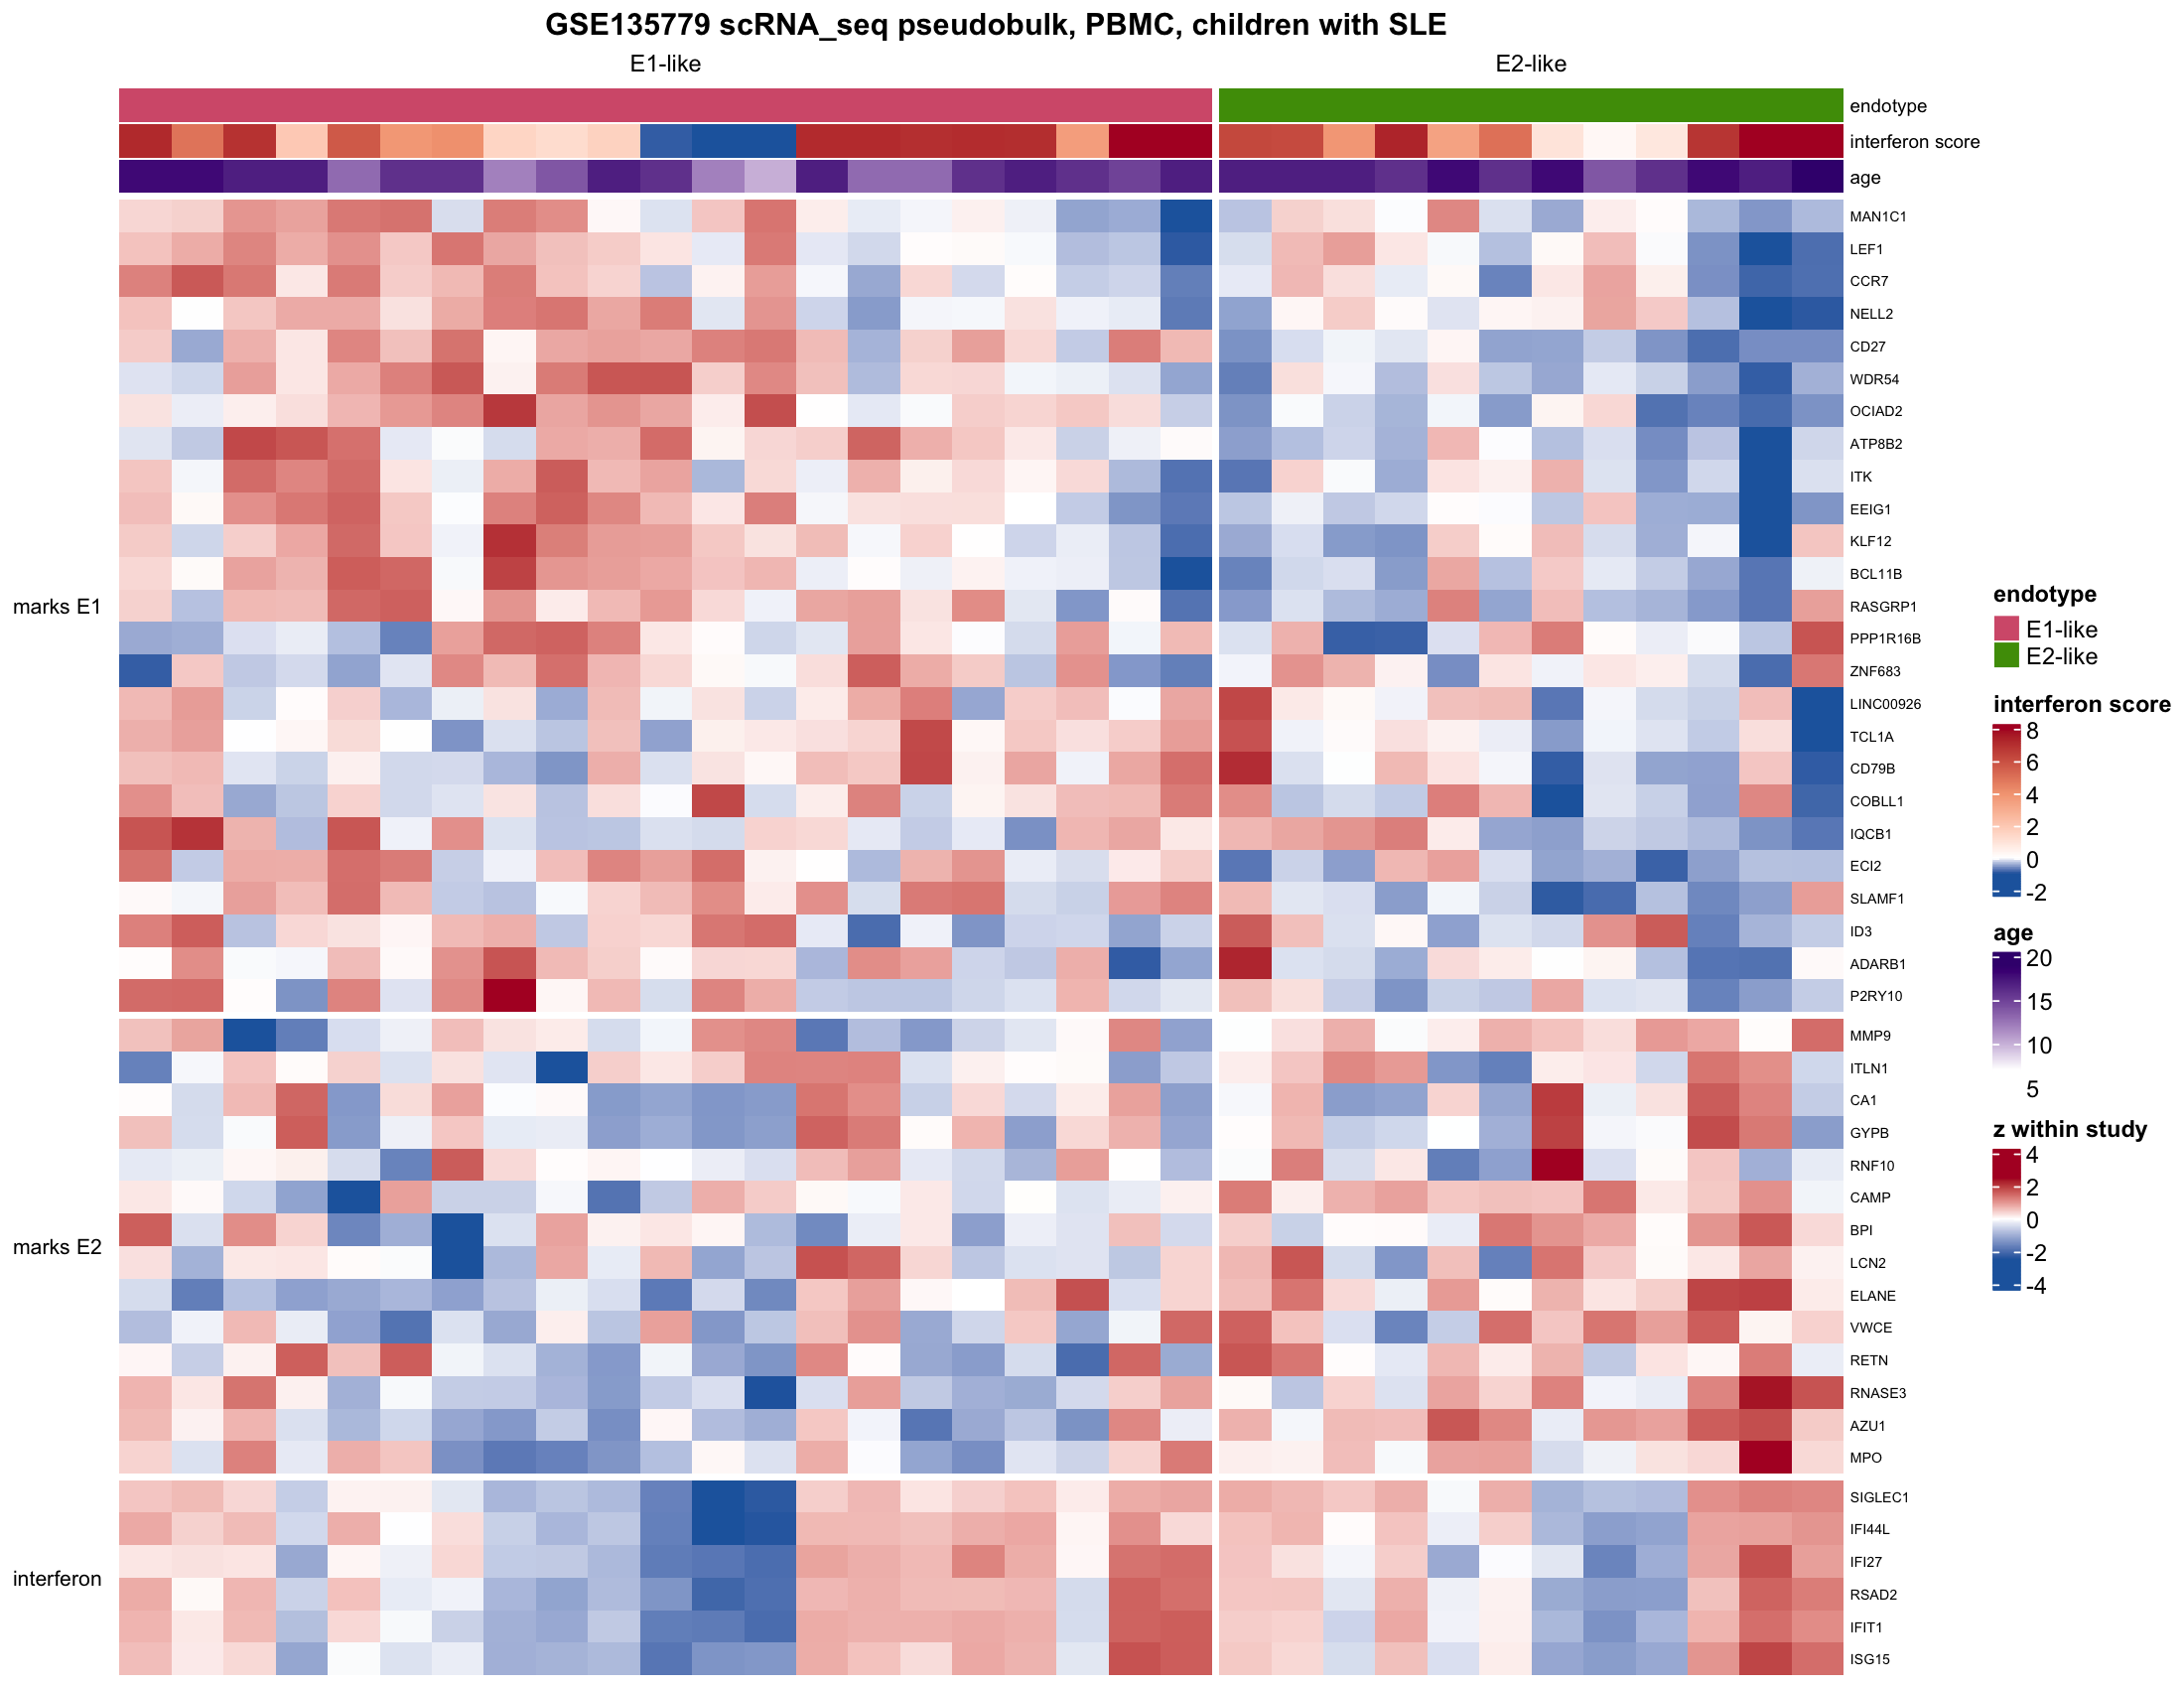

In [5]:
for (f in c("fig31_cross_platform_GSE65391_A.png", "fig31_cross_platform_GSE232381.png", "fig31_cross_platform_GSE135779.png"))
  IRdisplay::display_png(file = fig(f))

## Findings

The same pattern appears on all three platforms: E2-like patients are lower in the E1 (lymphocyte)
markers and higher in the E2 markers that each study measures. The contrast is sharpest in whole
blood. In PBMC it rests mainly on the lymphocyte side. Interferon genes vary within both endotypes in
every study and do not follow the split.